In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "market_prices.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,wti_price,brent_price
0,2015-01-02,52.689999,56.419998
1,2015-01-05,50.040001,53.110001
2,2015-01-06,47.930000,51.099998
3,2015-01-07,48.650002,51.150002
4,2015-01-08,48.790001,50.959999


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2936 non-null   datetime64[us]
 1   wti_price    2935 non-null   float64       
 2   brent_price  2936 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 68.9 KB


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df["wti_log_return"] = np.log(
    df["wti_price"] / df["wti_price"].shift(1)
)

df["brent_log_return"] = np.log(
    df["brent_price"] / df["brent_price"].shift(1)
)

df[[
    "date",
    "wti_price",
    "wti_log_return",
    "brent_log_return"
]].head(10)

c:\Users\anush\Documents\Codes\CrudeOilForecasting\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,wti_price,wti_log_return,brent_log_return
0,2015-01-02,52.689999,NaN,NaN
1,2015-01-05,50.040001,-0.051603,-0.060458
2,2015-01-06,47.930000,-0.043081,-0.038581
3,2015-01-07,48.650002,0.014910,0.000978
4,2015-01-08,48.790001,0.002874,-0.003722
5,2015-01-09,48.360001,-0.008852,-0.016820
6,2015-01-12,46.070000,-0.048511,-0.054966
7,2015-01-13,45.889999,-0.003915,-0.017869
8,2015-01-14,48.480000,0.054904,0.044088
9,2015-01-15,46.250000,-0.047090,-0.021171


In [5]:
df["target_return"] = df["wti_log_return"].shift(-1)
df[[
    "date",
    "wti_price",
    "wti_log_return",
    "target_return"
]].head(10)

,date,wti_price,wti_log_return,target_return
0,2015-01-02,52.689999,NaN,-0.051603
1,2015-01-05,50.040001,-0.051603,-0.043081
2,2015-01-06,47.930000,-0.043081,0.014910
3,2015-01-07,48.650002,0.014910,0.002874
4,2015-01-08,48.790001,0.002874,-0.008852
5,2015-01-09,48.360001,-0.008852,-0.048511
6,2015-01-12,46.070000,-0.048511,-0.003915
7,2015-01-13,45.889999,-0.003915,0.054904
8,2015-01-14,48.480000,0.054904,-0.047090
9,2015-01-15,46.250000,-0.047090,0.051412


In [6]:
for lag in [1, 2, 3, 5, 10]:
    df[f"wti_return_lag_{lag}"] = (
        df["wti_log_return"].shift(lag)
    )

df[[
    "date",
    "wti_log_return",
    "wti_return_lag_1",
    "wti_return_lag_2",
    "wti_return_lag_3",
    "wti_return_lag_5",
    "wti_return_lag_10"
]].tail(10)

,date,wti_log_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10
2926,2026-08-21,-0.008806,0.023035,0.010423,0.005194,0.014055,0.011449
2927,2026-08-24,-0.023829,-0.008806,0.023035,0.010423,0.025166,0.049289
2928,2026-08-25,-0.031669,-0.023829,-0.008806,0.023035,0.005194,0.012944
2929,2026-08-26,-0.001580,-0.031669,-0.023829,-0.008806,0.010423,0.000841
2930,2026-08-27,0.015686,-0.001580,-0.031669,-0.023829,0.023035,-0.024557
2931,2026-08-28,-0.001558,0.015686,-0.001580,-0.031669,-0.008806,0.014055
2932,2026-08-31,0.027904,-0.001558,0.015686,-0.001580,-0.023829,0.025166
2933,2026-09-01,0.050698,0.027904,-0.001558,0.015686,-0.031669,0.005194
2934,2026-09-02,0.008718,0.050698,0.027904,-0.001558,-0.001580,0.010423
2935,2026-09-03,-0.011938,0.008718,0.050698,0.027904,0.015686,0.023035


In [7]:
for window in [5, 10, 20, 50]:
    df[f"wti_momentum_{window}"] = (
        df["wti_price"] / df["wti_price"].shift(window) - 1
    )

df[[
    "date",
    "wti_price",
    "wti_momentum_5",
    "wti_momentum_10",
    "wti_momentum_20",
    "wti_momentum_50"
]].tail()

,date,wti_price,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50
2931,2026-08-28,83.400002,-0.042040,0.012136,-0.014999,0.086079
2932,2026-08-31,85.760002,0.008822,0.014911,0.067463,0.119582
2933,2026-09-01,90.220001,0.095435,0.062162,0.190709,0.205827
2934,2026-09-02,91.010002,0.106774,0.060352,0.209918,0.243136
2935,2026-09-03,89.930000,0.076619,0.023910,0.163540,0.278504


In [8]:
for window in [5, 10, 20, 50]:
    df[f"wti_ma_{window}"] = (
        df["wti_price"].rolling(window).mean()
    )
for window in [5, 10, 20, 50]:
    df[f"wti_price_ma_ratio_{window}"] = (
        df["wti_price"] / df[f"wti_ma_{window}"] - 1
    )
df[[
    "date",
    "wti_price",
    "wti_ma_20",
    "wti_price_ma_ratio_20",
    "wti_ma_50",
    "wti_price_ma_ratio_50"
]].tail()

,date,wti_price,wti_ma_20,wti_price_ma_ratio_20,wti_ma_50,wti_price_ma_ratio_50
2931,2026-08-28,83.400002,82.2870,0.013526,79.2992,0.051713
2932,2026-08-31,85.760002,82.5580,0.038785,79.4824,0.078981
2933,2026-09-01,90.220001,83.2805,0.083327,79.7904,0.130712
2934,2026-09-02,91.010002,84.0700,0.082550,80.1464,0.135547
2935,2026-09-03,89.930000,84.7020,0.061722,80.5382,0.116613


In [9]:
for window in [5, 10, 20]:
    df[f"wti_volatility_{window}"] = (
        df["wti_log_return"].rolling(window).std()
    )
df[[
    "date",
    "wti_volatility_5",
    "wti_volatility_10",
    "wti_volatility_20"
]].tail()

,date,wti_volatility_5,wti_volatility_10,wti_volatility_20
2931,2026-08-28,0.019058,0.018810,0.026845
2932,2026-08-31,0.022456,0.019213,0.024617
2933,2026-09-01,0.022013,0.024774,0.022176
2934,2026-09-02,0.020094,0.024746,0.021854
2935,2026-09-03,0.024899,0.024520,0.021943


In [10]:
df["brent_wti_spread"] = (
    df["brent_price"] - df["wti_price"]
)
df["spread_change_1d"] = (
    df["brent_wti_spread"].diff()
)
df["brent_wti_ratio"] = (
    df["brent_price"] / df["wti_price"]
)
spread_mean = df["brent_wti_spread"].rolling(20).mean()
spread_std = df["brent_wti_spread"].rolling(20).std()

df["spread_zscore_20"] = (
    (df["brent_wti_spread"] - spread_mean)
    / spread_std
)
df[[
    "date",
    "brent_wti_spread",
    "spread_change_1d",
    "brent_wti_ratio",
    "spread_zscore_20"
]].tail()

,date,brent_wti_spread,spread_change_1d,brent_wti_ratio,spread_zscore_20
2931,2026-08-28,5.909996,-0.260002,1.070863,0.246559
2932,2026-08-31,4.729996,-1.180000,1.055154,-1.164726
2933,2026-09-01,4.430000,-0.299995,1.049102,-1.754949
2934,2026-09-02,4.619995,0.189995,1.050764,-1.610947
2935,2026-09-03,4.559998,-0.059998,1.050706,-1.562767


In [11]:
for lag in [1, 2, 3, 5, 10]:
    df[f"brent_return_lag_{lag}"] = (
        df["brent_log_return"].shift(lag)
    )

In [12]:
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

In [13]:
pd.set_option("display.max_columns", None)

df.head()

,date,wti_price,brent_price,wti_log_return,brent_log_return,target_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50,wti_ma_5,wti_ma_10,wti_ma_20,wti_ma_50,wti_price_ma_ratio_5,wti_price_ma_ratio_10,wti_price_ma_ratio_20,wti_price_ma_ratio_50,wti_volatility_5,wti_volatility_10,wti_volatility_20,brent_wti_spread,spread_change_1d,brent_wti_ratio,spread_zscore_20,brent_return_lag_1,brent_return_lag_2,brent_return_lag_3,brent_return_lag_5,brent_return_lag_10,day_of_week,month
0,2015-01-02,52.689999,56.419998,NaN,NaN,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.730000,NaN,1.070791,NaN,NaN,NaN,NaN,NaN,NaN,4,1
1,2015-01-05,50.040001,53.110001,-0.051603,-0.060458,-0.043081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.070000,-0.660000,1.061351,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2,2015-01-06,47.930000,51.099998,-0.043081,-0.038581,0.014910,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.169998,0.099998,1.066138,NaN,-0.060458,NaN,NaN,NaN,NaN,1,1
3,2015-01-07,48.650002,51.150002,0.014910,0.000978,0.002874,-0.043081,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,-0.669998,1.051387,NaN,-0.038581,-0.060458,NaN,NaN,NaN,2,1
4,2015-01-08,48.790001,50.959999,0.002874,-0.003722,-0.008852,0.014910,-0.043081,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,49.62,NaN,NaN,NaN,-0.016727,NaN,NaN,NaN,NaN,NaN,NaN,2.169998,-0.330002,1.044476,NaN,0.000978,-0.038581,-0.060458,NaN,NaN,3,1


In [14]:
print("Number of columns:", len(df.columns))

for column in df.columns:
    print(column)

Number of columns: 37
date
wti_price
brent_price
wti_log_return
brent_log_return
target_return
wti_return_lag_1
wti_return_lag_2
wti_return_lag_3
wti_return_lag_5
wti_return_lag_10
wti_momentum_5
wti_momentum_10
wti_momentum_20
wti_momentum_50
wti_ma_5
wti_ma_10
wti_ma_20
wti_ma_50
wti_price_ma_ratio_5
wti_price_ma_ratio_10
wti_price_ma_ratio_20
wti_price_ma_ratio_50
wti_volatility_5
wti_volatility_10
wti_volatility_20
brent_wti_spread
spread_change_1d
brent_wti_ratio
spread_zscore_20
brent_return_lag_1
brent_return_lag_2
brent_return_lag_3
brent_return_lag_5
brent_return_lag_10
day_of_week
month


In [15]:
missing = df.isna().sum()

missing[missing > 0].sort_values(ascending=False)

wti_ma_50                99
wti_price_ma_ratio_50    99
wti_volatility_20        62
wti_momentum_50          52
spread_zscore_20         39
wti_ma_20                39
wti_price_ma_ratio_20    39
wti_volatility_10        32
wti_momentum_20          22
wti_price_ma_ratio_10    19
wti_ma_10                19
wti_volatility_5         17
wti_return_lag_10        15
wti_momentum_10          12
brent_return_lag_10      11
wti_return_lag_5         10
wti_price_ma_ratio_5      9
wti_ma_5                  9
wti_return_lag_3          8
wti_momentum_5            7
wti_return_lag_2          7
wti_return_lag_1          6
brent_return_lag_5        6
target_return             5
wti_log_return            5
brent_return_lag_3        4
brent_return_lag_2        3
spread_change_1d          3
brent_return_lag_1        2
wti_price                 1
brent_log_return          1
brent_wti_spread          1
brent_wti_ratio           1
dtype: int64

In [16]:
feature_columns = [
    "wti_return_lag_1",
    "wti_return_lag_2",
    "wti_return_lag_3",
    "wti_return_lag_5",
    "wti_return_lag_10",

    "wti_momentum_5",
    "wti_momentum_10",
    "wti_momentum_20",
    "wti_momentum_50",

    "wti_price_ma_ratio_5",
    "wti_price_ma_ratio_10",
    "wti_price_ma_ratio_20",
    "wti_price_ma_ratio_50",

    "wti_volatility_5",
    "wti_volatility_10",
    "wti_volatility_20",

    "brent_return_lag_1",
    "brent_return_lag_2",
    "brent_return_lag_3",
    "brent_return_lag_5",
    "brent_return_lag_10",

    "spread_change_1d",
    "brent_wti_ratio",
    "spread_zscore_20",

    "day_of_week",
    "month",
    "dxy_return_lag_1",
    "sp500_return_lag_1",
    "vix_change_lag_1",
    "natural_gas_return_lag_1",
    "gold_return_lag_1",
    "us10y_change_lag_1"
]
available_feature_columns = [
    column for column in feature_columns if column in df.columns
]
model_df = df[
    ["date", "wti_price", "target_return"] + available_feature_columns
].copy()

model_df = model_df.dropna().reset_index(drop=True)

model_df.head()

,date,wti_price,target_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50,wti_price_ma_ratio_5,wti_price_ma_ratio_10,wti_price_ma_ratio_20,wti_price_ma_ratio_50,wti_volatility_5,wti_volatility_10,wti_volatility_20,brent_return_lag_1,brent_return_lag_2,brent_return_lag_3,brent_return_lag_5,brent_return_lag_10,spread_change_1d,brent_wti_ratio,spread_zscore_20,day_of_week,month
0,2015-03-17,43.459999,0.027237,-0.021642,-0.048110,-0.023526,-0.034798,0.018580,-0.100021,-0.139747,-0.188119,-0.175176,-0.044415,-0.090014,-0.112146,-0.107704,0.017421,0.019959,0.024208,-0.022756,-0.043139,-0.008027,-0.037248,0.024553,0.410004,1.229406,0.145675,1,3
1,2015-03-18,44.660000,-0.015798,-0.009618,-0.021642,-0.048110,-0.002488,0.019795,-0.072867,-0.133320,-0.143460,-0.107514,-0.002635,-0.051241,-0.080606,-0.081036,0.027504,0.021483,0.025295,-0.000187,-0.022756,-0.043139,0.020189,-0.007732,1.279999,1.251903,1.186653,2,3
2,2015-03-19,43.959999,0.039256,0.027237,-0.009618,-0.021642,-0.023526,-0.015056,-0.065675,-0.133964,-0.140735,-0.082829,-0.004529,-0.052423,-0.088260,-0.093959,0.027129,0.021487,0.025231,0.045371,-0.000187,-0.022756,-0.008027,-0.001157,-0.779999,1.238171,0.414304,3,3
3,2015-03-20,45.720001,0.037141,-0.015798,0.027237,-0.009618,-0.048110,-0.022916,0.019625,-0.078412,-0.091776,-0.060226,0.031216,-0.006152,-0.047192,-0.056545,0.027467,0.027025,0.027205,-0.026828,0.045371,-0.000187,-0.043139,-0.012478,-0.870003,1.209974,-0.378647,4,3
4,2015-03-23,47.450001,0.001264,0.039256,-0.015798,0.027237,-0.021642,0.007831,0.081358,-0.051000,-0.040445,-0.027465,0.053274,0.037204,-0.009074,-0.020304,0.026367,0.030339,0.028563,0.016219,-0.026828,0.045371,-0.022756,-0.020295,-1.130001,1.178504,-1.319828,0,3


In [17]:
print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

print("\nMissing values:")
print(model_df.isna().sum().sum())

Rows: 2811
Columns: 29

Missing values:
0


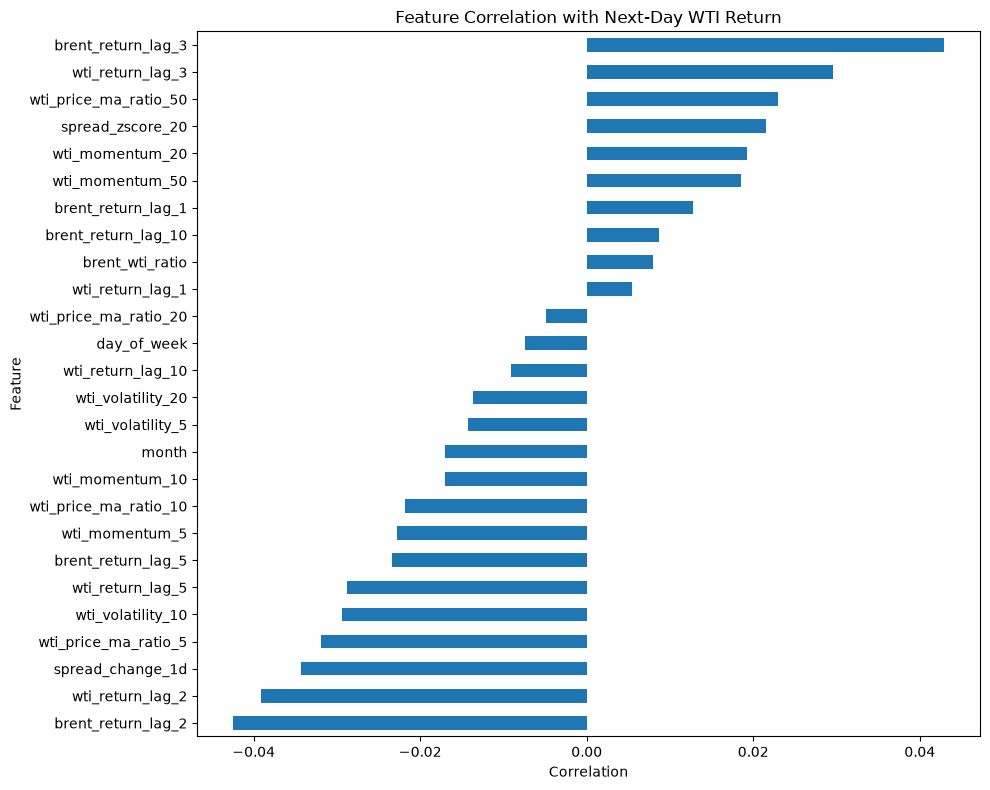

In [18]:
correlation_features = [
    column for column in feature_columns
    if column in model_df.columns
]

correlations = (
    model_df[correlation_features + ["target_return"]]
    .corr()["target_return"]
    .drop("target_return")
    .sort_values()
)

correlations

plt.figure(figsize=(10, 8))

correlations.plot(kind="barh")

plt.title("Feature Correlation with Next-Day WTI Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# MACRO / MARKET DATA
# ============================================================

import yfinance as yf

market_tickers = {
    "dxy": "DX-Y.NYB",
    "sp500": "^GSPC",
    "vix": "^VIX",
    "natural_gas": "NG=F",
    "gold": "GC=F",
    "us10y": "^TNX"
}

start_date = df["date"].min().strftime("%Y-%m-%d")
end_date = (df["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

market_data = {}

for name, ticker in market_tickers.items():
    print(f"Downloading {name} ({ticker})...")

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    # Handle yfinance multi-level columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    market_data[name] = data["Close"]

market_df = pd.DataFrame(market_data)

market_df.index = pd.to_datetime(market_df.index)
market_df = market_df.reset_index()
market_df = market_df.rename(columns={"Date": "date"})

market_df.head()

,date,dxy,sp500,vix,natural_gas,gold,us10y
0,2015-01-02,91.080002,2058.199951,17.790001,3.003,1186.000000,2.123
1,2015-01-05,91.379997,2020.579956,19.920000,2.882,1203.900024,2.039
2,2015-01-06,91.500000,2002.609985,21.120001,2.938,1219.300049,1.963
3,2015-01-07,91.889999,2025.900024,19.309999,2.871,1210.599976,1.954
4,2015-01-08,92.370003,2062.139893,17.010000,2.927,1208.400024,2.016


In [20]:
# ============================================================
# MARKET FEATURE ENGINEERING
# ============================================================

# Daily percentage/log changes for market variables

market_df["dxy_return"] = np.log(
    market_df["dxy"] / market_df["dxy"].shift(1)
)

market_df["sp500_return"] = np.log(
    market_df["sp500"] / market_df["sp500"].shift(1)
)

market_df["vix_change"] = (
    market_df["vix"].pct_change()
)

market_df["natural_gas_return"] = np.log(
    market_df["natural_gas"] / market_df["natural_gas"].shift(1)
)

market_df["gold_return"] = np.log(
    market_df["gold"] / market_df["gold"].shift(1)
)

market_df["us10y_change"] = (
    market_df["us10y"].diff()
)

market_df.head()

,date,dxy,sp500,vix,natural_gas,gold,us10y,dxy_return,sp500_return,vix_change,natural_gas_return,gold_return,us10y_change
0,2015-01-02,91.080002,2058.199951,17.790001,3.003,1186.000000,2.123,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,91.379997,2020.579956,19.920000,2.882,1203.900024,2.039,0.003288,-0.018447,0.119730,-0.041127,0.014980,-0.084
2,2015-01-06,91.500000,2002.609985,21.120001,2.938,1219.300049,1.963,0.001312,-0.008933,0.060241,0.019245,0.012711,-0.076
3,2015-01-07,91.889999,2025.900024,19.309999,2.871,1210.599976,1.954,0.004253,0.011563,-0.085701,-0.023069,-0.007161,-0.009
4,2015-01-08,92.370003,2062.139893,17.010000,2.927,1208.400024,2.016,0.005210,0.017730,-0.119109,0.019318,-0.001819,0.062


In [21]:
# ============================================================
# LAGGED MARKET FEATURES
# ============================================================

market_features = [
    "dxy_return",
    "sp500_return",
    "vix_change",
    "natural_gas_return",
    "gold_return",
    "us10y_change"
]

for feature in market_features:
    market_df[f"{feature}_lag_1"] = market_df[feature].shift(1)

market_df.head()

,date,dxy,sp500,vix,natural_gas,gold,us10y,dxy_return,sp500_return,vix_change,natural_gas_return,gold_return,us10y_change,dxy_return_lag_1,sp500_return_lag_1,vix_change_lag_1,natural_gas_return_lag_1,gold_return_lag_1,us10y_change_lag_1
0,2015-01-02,91.080002,2058.199951,17.790001,3.003,1186.000000,2.123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,91.379997,2020.579956,19.920000,2.882,1203.900024,2.039,0.003288,-0.018447,0.119730,-0.041127,0.014980,-0.084,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,91.500000,2002.609985,21.120001,2.938,1219.300049,1.963,0.001312,-0.008933,0.060241,0.019245,0.012711,-0.076,0.003288,-0.018447,0.119730,-0.041127,0.014980,-0.084
3,2015-01-07,91.889999,2025.900024,19.309999,2.871,1210.599976,1.954,0.004253,0.011563,-0.085701,-0.023069,-0.007161,-0.009,0.001312,-0.008933,0.060241,0.019245,0.012711,-0.076
4,2015-01-08,92.370003,2062.139893,17.010000,2.927,1208.400024,2.016,0.005210,0.017730,-0.119109,0.019318,-0.001819,0.062,0.004253,0.011563,-0.085701,-0.023069,-0.007161,-0.009


In [22]:
# ============================================================
# MERGE MARKET FEATURES WITH OIL DATA
# ============================================================

# Keep only the features we want to use
market_feature_columns = [
    "date",
    "dxy_return_lag_1",
    "sp500_return_lag_1",
    "vix_change_lag_1",
    "natural_gas_return_lag_1",
    "gold_return_lag_1",
    "us10y_change_lag_1"
]

market_features_df = market_df[market_feature_columns].copy()

# Replace existing macro features and merge leftovers when rerunning this cell
macro_columns = set(market_feature_columns) - {"date"}
df = df.drop(
    columns=[
        column for column in df.columns
        if column in macro_columns
        or any(column.startswith(f"{macro}_") for macro in macro_columns)
    ]
)

# Merge using date
df = df.merge(
    market_features_df,
    on="date",
    how="left"
)

# Rebuild the model dataset after macro features are available
model_df = df[
    ["date", "wti_price", "target_return"] + feature_columns
].copy()
model_df = model_df.dropna().reset_index(drop=True)

df.head()

,date,wti_price,brent_price,wti_log_return,brent_log_return,target_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50,wti_ma_5,wti_ma_10,wti_ma_20,wti_ma_50,wti_price_ma_ratio_5,wti_price_ma_ratio_10,wti_price_ma_ratio_20,wti_price_ma_ratio_50,wti_volatility_5,wti_volatility_10,wti_volatility_20,brent_wti_spread,spread_change_1d,brent_wti_ratio,spread_zscore_20,brent_return_lag_1,brent_return_lag_2,brent_return_lag_3,brent_return_lag_5,brent_return_lag_10,day_of_week,month,dxy_return_lag_1,sp500_return_lag_1,vix_change_lag_1,natural_gas_return_lag_1,gold_return_lag_1,us10y_change_lag_1
0,2015-01-02,52.689999,56.419998,NaN,NaN,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.730000,NaN,1.070791,NaN,NaN,NaN,NaN,NaN,NaN,4,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,50.040001,53.110001,-0.051603,-0.060458,-0.043081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.070000,-0.660000,1.061351,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,47.930000,51.099998,-0.043081,-0.038581,0.014910,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.169998,0.099998,1.066138,NaN,-0.060458,NaN,NaN,NaN,NaN,1,1,0.003288,-0.018447,0.119730,-0.041127,0.014980,-0.084
3,2015-01-07,48.650002,51.150002,0.014910,0.000978,0.002874,-0.043081,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,-0.669998,1.051387,NaN,-0.038581,-0.060458,NaN,NaN,NaN,2,1,0.001312,-0.008933,0.060241,0.019245,0.012711,-0.076
4,2015-01-08,48.790001,50.959999,0.002874,-0.003722,-0.008852,0.014910,-0.043081,-0.051603,NaN,NaN,NaN,NaN,NaN,NaN,49.62,NaN,NaN,NaN,-0.016727,NaN,NaN,NaN,NaN,NaN,NaN,2.169998,-0.330002,1.044476,NaN,0.000978,-0.038581,-0.060458,NaN,NaN,3,1,0.004253,0.011563,-0.085701,-0.023069,-0.007161,-0.009


In [23]:
OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_dataset.csv"
)

model_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved feature-engineered dataset to:")
print(OUTPUT_PATH)

Saved feature-engineered dataset to:
c:\Users\anush\Documents\Codes\CrudeOilForecasting\data\processed\model_dataset.csv


In [24]:
print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))
print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nMissing values:")
print(model_df.isna().sum())

Rows: 2793
Columns: 35

Columns:
['date', 'wti_price', 'target_return', 'wti_return_lag_1', 'wti_return_lag_2', 'wti_return_lag_3', 'wti_return_lag_5', 'wti_return_lag_10', 'wti_momentum_5', 'wti_momentum_10', 'wti_momentum_20', 'wti_momentum_50', 'wti_price_ma_ratio_5', 'wti_price_ma_ratio_10', 'wti_price_ma_ratio_20', 'wti_price_ma_ratio_50', 'wti_volatility_5', 'wti_volatility_10', 'wti_volatility_20', 'brent_return_lag_1', 'brent_return_lag_2', 'brent_return_lag_3', 'brent_return_lag_5', 'brent_return_lag_10', 'spread_change_1d', 'brent_wti_ratio', 'spread_zscore_20', 'day_of_week', 'month', 'dxy_return_lag_1', 'sp500_return_lag_1', 'vix_change_lag_1', 'natural_gas_return_lag_1', 'gold_return_lag_1', 'us10y_change_lag_1']

First 5 rows:


,date,wti_price,target_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50,wti_price_ma_ratio_5,wti_price_ma_ratio_10,wti_price_ma_ratio_20,wti_price_ma_ratio_50,wti_volatility_5,wti_volatility_10,wti_volatility_20,brent_return_lag_1,brent_return_lag_2,brent_return_lag_3,brent_return_lag_5,brent_return_lag_10,spread_change_1d,brent_wti_ratio,spread_zscore_20,day_of_week,month,dxy_return_lag_1,sp500_return_lag_1,vix_change_lag_1,natural_gas_return_lag_1,gold_return_lag_1,us10y_change_lag_1
0,2015-03-17,43.459999,0.027237,-0.021642,-0.048110,-0.023526,-0.034798,0.018580,-0.100021,-0.139747,-0.188119,-0.175176,-0.044415,-0.090014,-0.112146,-0.107704,0.017421,0.019959,0.024208,-0.022756,-0.043139,-0.008027,-0.037248,0.024553,0.410004,1.229406,0.145675,1,3,-0.007303,0.013443,-0.024375,-0.004042,0.000607,-0.014
1,2015-03-18,44.660000,-0.015798,-0.009618,-0.021642,-0.048110,-0.002488,0.019795,-0.072867,-0.133320,-0.143460,-0.107514,-0.002635,-0.051241,-0.080606,-0.081036,0.027504,0.021483,0.025295,-0.000187,-0.022756,-0.043139,0.020189,-0.007732,1.279999,1.251903,1.186653,2,3,-0.000100,-0.003326,0.003203,0.049912,-0.004345,-0.040
2,2015-03-19,43.959999,0.039256,0.027237,-0.009618,-0.021642,-0.023526,-0.015056,-0.065675,-0.133964,-0.140735,-0.082829,-0.004529,-0.052423,-0.088260,-0.093959,0.027129,0.021487,0.025231,0.045371,-0.000187,-0.022756,-0.008027,-0.001157,-0.779999,1.238171,0.414304,3,3,-0.010498,0.012085,-0.107918,0.022512,0.002696,-0.107
3,2015-03-20,45.720001,0.037141,-0.015798,0.027237,-0.009618,-0.048110,-0.022916,0.019625,-0.078412,-0.091776,-0.060226,0.031216,-0.006152,-0.047192,-0.056545,0.027467,0.027025,0.027205,-0.026828,0.045371,-0.000187,-0.043139,-0.012478,-0.870003,1.209974,-0.378647,4,3,0.005565,-0.004884,0.007158,-0.037332,0.015256,0.026
4,2015-03-23,47.450001,0.001264,0.039256,-0.015798,0.027237,-0.021642,0.007831,0.081358,-0.051000,-0.040445,-0.027465,0.053274,0.037204,-0.009074,-0.020304,0.026367,0.030339,0.028563,0.016219,-0.026828,0.045371,-0.022756,-0.020295,-1.130001,1.178504,-1.319828,0,3,-0.012081,0.008972,-0.074627,-0.009645,0.013340,-0.047



Missing values:
date                        0
wti_price                   0
target_return               0
wti_return_lag_1            0
wti_return_lag_2            0
wti_return_lag_3            0
wti_return_lag_5            0
wti_return_lag_10           0
wti_momentum_5              0
wti_momentum_10             0
wti_momentum_20             0
wti_momentum_50             0
wti_price_ma_ratio_5        0
wti_price_ma_ratio_10       0
wti_price_ma_ratio_20       0
wti_price_ma_ratio_50       0
wti_volatility_5            0
wti_volatility_10           0
wti_volatility_20           0
brent_return_lag_1          0
brent_return_lag_2          0
brent_return_lag_3          0
brent_return_lag_5          0
brent_return_lag_10         0
spread_change_1d            0
brent_wti_ratio             0
spread_zscore_20            0
day_of_week                 0
month                       0
dxy_return_lag_1            0
sp500_return_lag_1          0
vix_change_lag_1            0
natural_gas_return_lag_

In [25]:
market_df.head()
market_df.isna().sum()

date                         0
dxy                          6
sp500                        8
vix                          6
natural_gas                  5
gold                         7
us10y                        9
dxy_return                  13
sp500_return                16
vix_change                  13
natural_gas_return          11
gold_return                 15
us10y_change                18
dxy_return_lag_1            14
sp500_return_lag_1          16
vix_change_lag_1            14
natural_gas_return_lag_1    12
gold_return_lag_1           16
us10y_change_lag_1          18
dtype: int64

In [26]:
print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))
print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nMissing values:")
print(model_df.isna().sum())

Rows: 2793
Columns: 35

Columns:
['date', 'wti_price', 'target_return', 'wti_return_lag_1', 'wti_return_lag_2', 'wti_return_lag_3', 'wti_return_lag_5', 'wti_return_lag_10', 'wti_momentum_5', 'wti_momentum_10', 'wti_momentum_20', 'wti_momentum_50', 'wti_price_ma_ratio_5', 'wti_price_ma_ratio_10', 'wti_price_ma_ratio_20', 'wti_price_ma_ratio_50', 'wti_volatility_5', 'wti_volatility_10', 'wti_volatility_20', 'brent_return_lag_1', 'brent_return_lag_2', 'brent_return_lag_3', 'brent_return_lag_5', 'brent_return_lag_10', 'spread_change_1d', 'brent_wti_ratio', 'spread_zscore_20', 'day_of_week', 'month', 'dxy_return_lag_1', 'sp500_return_lag_1', 'vix_change_lag_1', 'natural_gas_return_lag_1', 'gold_return_lag_1', 'us10y_change_lag_1']

First 5 rows:


,date,wti_price,target_return,wti_return_lag_1,wti_return_lag_2,wti_return_lag_3,wti_return_lag_5,wti_return_lag_10,wti_momentum_5,wti_momentum_10,wti_momentum_20,wti_momentum_50,wti_price_ma_ratio_5,wti_price_ma_ratio_10,wti_price_ma_ratio_20,wti_price_ma_ratio_50,wti_volatility_5,wti_volatility_10,wti_volatility_20,brent_return_lag_1,brent_return_lag_2,brent_return_lag_3,brent_return_lag_5,brent_return_lag_10,spread_change_1d,brent_wti_ratio,spread_zscore_20,day_of_week,month,dxy_return_lag_1,sp500_return_lag_1,vix_change_lag_1,natural_gas_return_lag_1,gold_return_lag_1,us10y_change_lag_1
0,2015-03-17,43.459999,0.027237,-0.021642,-0.048110,-0.023526,-0.034798,0.018580,-0.100021,-0.139747,-0.188119,-0.175176,-0.044415,-0.090014,-0.112146,-0.107704,0.017421,0.019959,0.024208,-0.022756,-0.043139,-0.008027,-0.037248,0.024553,0.410004,1.229406,0.145675,1,3,-0.007303,0.013443,-0.024375,-0.004042,0.000607,-0.014
1,2015-03-18,44.660000,-0.015798,-0.009618,-0.021642,-0.048110,-0.002488,0.019795,-0.072867,-0.133320,-0.143460,-0.107514,-0.002635,-0.051241,-0.080606,-0.081036,0.027504,0.021483,0.025295,-0.000187,-0.022756,-0.043139,0.020189,-0.007732,1.279999,1.251903,1.186653,2,3,-0.000100,-0.003326,0.003203,0.049912,-0.004345,-0.040
2,2015-03-19,43.959999,0.039256,0.027237,-0.009618,-0.021642,-0.023526,-0.015056,-0.065675,-0.133964,-0.140735,-0.082829,-0.004529,-0.052423,-0.088260,-0.093959,0.027129,0.021487,0.025231,0.045371,-0.000187,-0.022756,-0.008027,-0.001157,-0.779999,1.238171,0.414304,3,3,-0.010498,0.012085,-0.107918,0.022512,0.002696,-0.107
3,2015-03-20,45.720001,0.037141,-0.015798,0.027237,-0.009618,-0.048110,-0.022916,0.019625,-0.078412,-0.091776,-0.060226,0.031216,-0.006152,-0.047192,-0.056545,0.027467,0.027025,0.027205,-0.026828,0.045371,-0.000187,-0.043139,-0.012478,-0.870003,1.209974,-0.378647,4,3,0.005565,-0.004884,0.007158,-0.037332,0.015256,0.026
4,2015-03-23,47.450001,0.001264,0.039256,-0.015798,0.027237,-0.021642,0.007831,0.081358,-0.051000,-0.040445,-0.027465,0.053274,0.037204,-0.009074,-0.020304,0.026367,0.030339,0.028563,0.016219,-0.026828,0.045371,-0.022756,-0.020295,-1.130001,1.178504,-1.319828,0,3,-0.012081,0.008972,-0.074627,-0.009645,0.013340,-0.047



Missing values:
date                        0
wti_price                   0
target_return               0
wti_return_lag_1            0
wti_return_lag_2            0
wti_return_lag_3            0
wti_return_lag_5            0
wti_return_lag_10           0
wti_momentum_5              0
wti_momentum_10             0
wti_momentum_20             0
wti_momentum_50             0
wti_price_ma_ratio_5        0
wti_price_ma_ratio_10       0
wti_price_ma_ratio_20       0
wti_price_ma_ratio_50       0
wti_volatility_5            0
wti_volatility_10           0
wti_volatility_20           0
brent_return_lag_1          0
brent_return_lag_2          0
brent_return_lag_3          0
brent_return_lag_5          0
brent_return_lag_10         0
spread_change_1d            0
brent_wti_ratio             0
spread_zscore_20            0
day_of_week                 0
month                       0
dxy_return_lag_1            0
sp500_return_lag_1          0
vix_change_lag_1            0
natural_gas_return_lag_

In [27]:
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "model_dataset.csv"

model_df.to_csv(PROCESSED_PATH, index=False)

print(f"Saved final model dataset to: {PROCESSED_PATH}")

Saved final model dataset to: c:\Users\anush\Documents\Codes\CrudeOilForecasting\data\processed\model_dataset.csv
